# Evaluation: GINE vs. GATv2 auf dem OpenFlights-Flugroutennetz

Dieses Notebook führt die Ergebnisse zusammen. Es trainiert nichts selbst, sondern liest:

- `processed/openflights_split.pt` (aus `data_prep_OpenFlights.ipynb`) für die Heuristik-Baselines,
- `processed/seeds_<Modell>_OpenFlights*.csv` und `processed/scores_<Modell>_OpenFlights.npz`
  (aus `GINE_OpenFlights.ipynb` und `GATV2_OpenFlights.ipynb`).

**Reihenfolge:** `data_prep_OpenFlights.ipynb` → `GINE_OpenFlights.ipynb` und `GATV2_OpenFlights.ipynb` →
dieses Notebook.

**Metriken (alle auf dem Test-Split, nie zur Modellauswahl verwendet):**
- **ROC-AUC:** Wahrscheinlichkeit, dass eine zufällige echte Route höher bewertet wird als ein zufälliges
  Negativ-Paar. 0.5 = Zufall, 1.0 = perfekt.
- **Average Precision (AP):** Fläche unter der Precision-Recall-Kurve. Bei 1:1 Positiven/Negativen liegt Zufall
  bei 0.5.
- Modelle: Mittelwert ± Standardabweichung über 5 Seeds (Gegenprobe Standardprotokoll: 3 Seeds), jeweils an
  der Epoche mit der besten Val-AUC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

from gnn_pipeline import load_bundle, split_graph
from gnn_pipeline.evaluation import heuristic_scores

bundle = load_bundle("processed/openflights_split.pt")
test = bundle.test

SURFACE, INK, MUTED, GRID, AXIS = "#ffffff", "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]   # feste Reihenfolge, farbfehlsicht-validiert

def style(ax, title=None, xlabel=None, ylabel=None, grid_axis="both"):
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    if grid_axis:
        ax.grid(True, axis=grid_axis, color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelcolor=INK, length=0)
    if title:
        ax.set_title(title, loc="left", color=INK, fontsize=12)
    if xlabel:
        ax.set_xlabel(xlabel, color=INK)
    if ylabel:
        ax.set_ylabel(ylabel, color=INK)

import os

def load_seeds(name):
    path = f"processed/seeds_{name}.csv"
    return pd.read_csv(path) if os.path.exists(path) else None

# Gegenproben sind optional (RUN_CHECKS in den Modell-Notebooks); fehlende Dateien werden übersprungen
candidates = {"GINE": "GINE_OpenFlights", "GATv2": "GATv2_OpenFlights",
              "GINE ohne Graph": "GINE_OpenFlights_ohne_graph", "GATv2 ohne Graph": "GATv2_OpenFlights_ohne_graph"}
seeds = {k: df for k, f in candidates.items() if (df := load_seeds(f)) is not None}
seeds_uniform = {k: df for k in ("GINE", "GATv2") if (df := load_seeds(f"{k}_OpenFlights_uniform")) is not None}
print("Geladen:", list(seeds), "| Standardprotokoll:", list(seeds_uniform) or "nicht gerechnet")

C:\Users\gurke\PycharmProjects\MethodenDerKI_GraphEmbedding\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\gurke\PycharmProjects\MethodenDerKI_GraphEmbedding\.venv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Split geladen: processed/openflights_split.pt
Knoten: 3214 {'America': 1225, 'Asia': 786, 'Europe': 565, 'Africa': 260, 'Pacific': 175, 'Australia': 112, 'Atlantic': 32, 'Other': 30, 'Indian': 29}, Kanten: 37716
Knotenfeatures (14): ['sphere_x', 'sphere_y', 'sphere_z', 'log_altitude', 'utc_offset', 'region_Africa', 'region_America', 'region_Asia', 'region_Atlantic', 'region_Australia', 'region_Europe', 'region_Indian', 'region_Pacific', 'region_Other']
Kantenfeatures (6): ['distance_km', 'n_airlines', 'n_route_entries', 'n_aircraft_types', 'codeshare_share', 'bidirectional']
train: msg-passing Kanten=21120, Label-Paare pos=9052 neg=9052
val: msg-passing Kanten=21120, Label-Paare pos=3772 neg=3772
test: msg-passing Kanten=21120, Label-Paare pos=3772 neg=3772
train: positive Label-Kanten im Message-Passing-Graph: 0/9052, davon Gegenrichtung im Graph: 0/9052 (0.0%)
val: positive Label-Kanten im Message-Passing-Graph: 0/3772, davon Gegenrichtung im Graph: 0/3772 (0.0%)
test: positive Label

## Gesamtergebnis (faires Protokoll: entfernungsgleiche Negative mit Loch)

In [2]:
labels = test.edge_label.numpy()
heur = heuristic_scores(test)
heur_names = {"-Distanz (Koordinaten)": "Luftlinie", "Gemeinsame Nachbarn": "Gemeinsame Nachbarn",
              "Adamic-Adar": "Adamic-Adar", "Preferential Attachment": "Preferential Attachment"}

rows = []
for key, name in heur_names.items():
    rows.append({"Methode": name, "Art": "Heuristik (ohne Lernen)",
                 "Test-ROC-AUC": roc_auc_score(labels, heur[key]), "± Std": 0.0,
                 "Test-AP": average_precision_score(labels, heur[key])})
for name, df in seeds.items():
    rows.append({"Methode": name, "Art": "MLP ohne Message Passing" if "ohne" in name else "GNN",
                 "Test-ROC-AUC": df["test_auc"].mean(), "± Std": df["test_auc"].std(), "Test-AP": df["test_ap"].mean()})
results = pd.DataFrame(rows).sort_values("Test-ROC-AUC", ascending=False).reset_index(drop=True)
results.round(4)

,Methode,Art,Test-ROC-AUC,± Std,Test-AP
0,GATv2,GNN,0.8352,0.0046,0.8248
1,GINE,GNN,0.8243,0.0009,0.8198
2,Adamic-Adar,Heuristik (ohne Lernen),0.7549,0.0000,0.7577
3,Gemeinsame Nachbarn,Heuristik (ohne Lernen),0.7419,0.0000,0.7334
4,Preferential Attachment,Heuristik (ohne Lernen),0.6870,0.0000,0.7041
5,Luftlinie,Heuristik (ohne Lernen),0.5680,0.0000,0.5773


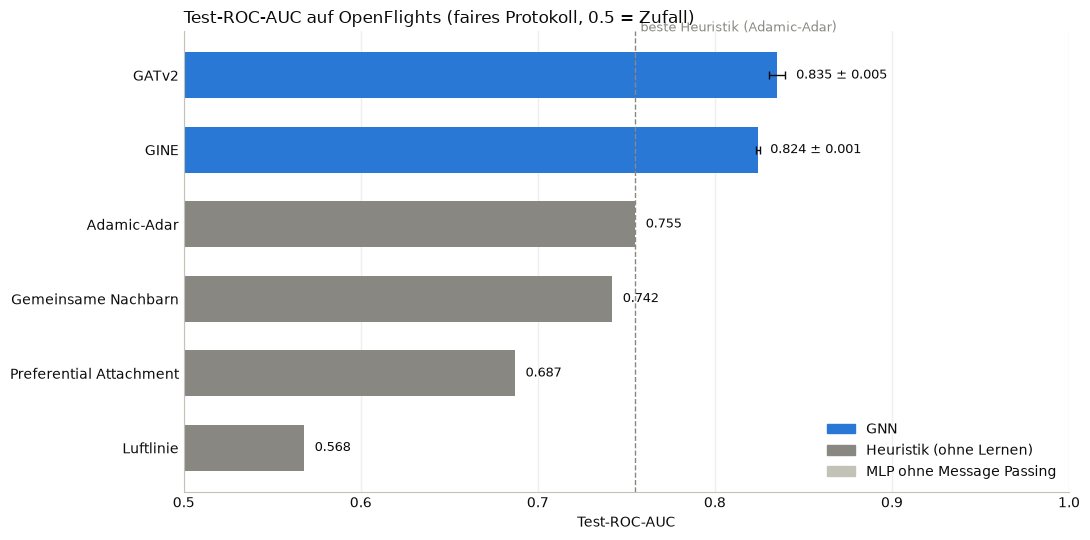

In [3]:
best_heuristic = results[results["Art"].str.startswith("Heuristik")].iloc[0]
plot_df = results.iloc[::-1]
kind_color = {"GNN": SERIES[0], "Heuristik (ohne Lernen)": MUTED, "MLP ohne Message Passing": AXIS}

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
y = np.arange(len(plot_df))
ax.barh(y, plot_df["Test-ROC-AUC"] - 0.5, left=0.5, height=0.62, color=[kind_color[k] for k in plot_df["Art"]],
        xerr=plot_df["± Std"].where(plot_df["± Std"] > 0), error_kw=dict(ecolor=INK, elinewidth=1, capsize=3))
for yi, (v, s) in enumerate(zip(plot_df["Test-ROC-AUC"], plot_df["± Std"])):
    ax.text(v + max(s, 0) + 0.006, yi, f"{v:.3f}" + (f" ± {s:.3f}" if s > 0 else ""), va="center", fontsize=9, color=INK)
ax.axvline(best_heuristic["Test-ROC-AUC"], color=MUTED, linestyle="--", linewidth=1)
ax.text(best_heuristic["Test-ROC-AUC"] + 0.003, len(plot_df) - 0.45, f"beste Heuristik ({best_heuristic['Methode']})",
        fontsize=9, color=MUTED, va="bottom")
ax.set_yticks(y, plot_df["Methode"])
ax.set_xlim(0.5, 1.0)
style(ax, "Test-ROC-AUC auf OpenFlights (faires Protokoll, 0.5 = Zufall)", "Test-ROC-AUC", None, grid_axis="x")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in kind_color.values()]
ax.legend(handles, kind_color.keys(), frameon=False, labelcolor=INK, loc="lower right")
fig.tight_layout()
plt.show()

## ROC- und Precision-Recall-Kurven

Modelle: jeweils der erste Trainingslauf aus dem Modell-Notebook (Seed 42, beste Val-Epoche). Zum Vergleich die
beiden stärksten Heuristiken und die Luftlinie.

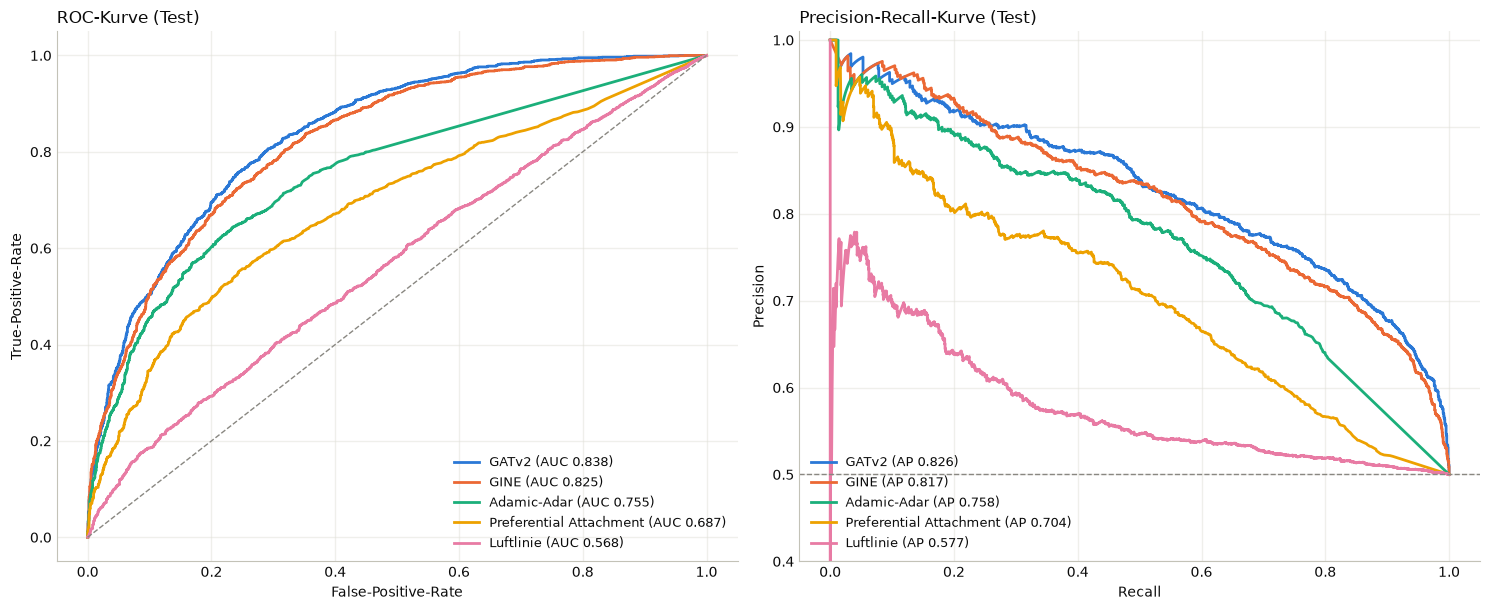

In [4]:
curves = {}
for name in ("GATv2", "GINE"):
    z = np.load(f"processed/scores_{name}_OpenFlights.npz")
    assert np.array_equal(z["labels"], labels), "Scores passen nicht zum aktuellen Split - Modell-Notebooks neu ausführen."
    curves[name] = z["scores"]
curves["Adamic-Adar"] = heur["Adamic-Adar"]
curves["Preferential Attachment"] = heur["Preferential Attachment"]
curves["Luftlinie"] = heur["-Distanz (Koordinaten)"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.2))
fig.patch.set_facecolor(SURFACE)
for (name, s), color in zip(curves.items(), SERIES):
    fpr, tpr, _ = roc_curve(labels, s)
    prec, rec, _ = precision_recall_curve(labels, s)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC {roc_auc_score(labels, s):.3f})")
    ax2.plot(rec, prec, color=color, linewidth=2, label=f"{name} (AP {average_precision_score(labels, s):.3f})")
ax1.plot([0, 1], [0, 1], color=MUTED, linestyle="--", linewidth=1)
ax2.axhline(labels.mean(), color=MUTED, linestyle="--", linewidth=1)
style(ax1, "ROC-Kurve (Test)", "False-Positive-Rate", "True-Positive-Rate")
style(ax2, "Precision-Recall-Kurve (Test)", "Recall", "Precision")
ax2.set_ylim(0.4, 1.01)
for ax in (ax1, ax2):
    ax.legend(frameon=False, labelcolor=INK, loc="lower right" if ax is ax1 else "lower left", fontsize=9)
fig.tight_layout()
plt.show()

## GINE vs. GATv2: Ist der Unterschied belastbar?

Welch-t-Test über die Test-ROC-AUC der 5 Seeds. Bei nur 5 Läufen ist das eine grobe Orientierung, kein strenger
Nachweis. Ein p-Wert unter 0.05 spricht dafür, dass der Unterschied nicht nur Seed-Rauschen ist.

In [5]:
g, a = seeds["GINE"]["test_auc"], seeds["GATv2"]["test_auc"]
t, p = stats.ttest_ind(a, g, equal_var=False)
display(pd.DataFrame({m: seeds[m][["val_auc", "test_auc", "test_ap", "best_epoch"]].agg(["mean", "std"]).stack()
                      for m in ("GINE", "GATv2")}).round(4))
print(f"Differenz GATv2 - GINE (Test-ROC-AUC): {a.mean() - g.mean():+.4f}, Welch-t = {t:.2f}, p = {p:.4f}")

GINE     GATv2
mean val_auc       0.8296    0.8378
     test_auc      0.8243    0.8352
     test_ap       0.8198    0.8248
     best_epoch  319.8000  407.4000
std  val_auc       0.0035    0.0029
     test_auc      0.0009    0.0046
     test_ap       0.0018    0.0048
     best_epoch    7.6942   79.2263

Differenz GATv2 - GINE (Test-ROC-AUC): +0.0109, Welch-t = 5.14, p = 0.0056


## Einordnung: faires Protokoll vs. Standardprotokoll

Im Standardprotokoll (zufällige Negative, wie in den meisten Veröffentlichungen) liegen die Werte viel höher,
aber schon die Luftlinie erreicht ≈ 0.94. Die Zahlen sind deshalb nicht direkt mit dem fairen Protokoll
vergleichbar. Entscheidend ist in beiden Fällen der **Abstand zur besten Heuristik**.

In [6]:
if len(seeds_uniform) < 2:
    print("Standardprotokoll nicht gerechnet (RUN_CHECKS = True in den Modell-Notebooks setzen).")
else:
    meta = bundle.meta
    uniform_test = split_graph(bundle.data, seed=meta["seed"], val_ratio=meta["val_ratio"], test_ratio=meta["test_ratio"],
                               neg_sampling_ratio=meta["neg_sampling_ratio"], neg_strategy="uniform",
                               supervision_ratio=meta["supervision_ratio"])[2]
    heur_u = heuristic_scores(uniform_test)
    labels_u = uniform_test.edge_label.numpy()

    def protocol_rows(hscores, lab, model_seeds):
        out = {name: roc_auc_score(lab, hscores[key]) for key, name in heur_names.items()}
        out.update({m: model_seeds[m]["test_auc"].mean() for m in ("GINE", "GATv2")})
        return out

    protocols = pd.DataFrame({
        "Standard (zufällige Negative)": protocol_rows(heur_u, labels_u, seeds_uniform),
        "Fair (entfernungsgleich, mit Loch)": protocol_rows(heur, labels, seeds),
    })
    protocols.loc["Abstand bestes GNN − beste Heuristik"] = (
        protocols.loc[["GINE", "GATv2"]].max() - protocols.loc[list(heur_names.values())].max())
    protocols.round(3)

Standardprotokoll nicht gerechnet (RUN_CHECKS = True in den Modell-Notebooks setzen).


In [7]:
if len(seeds_uniform) < 2:
    print("Standardprotokoll nicht gerechnet (RUN_CHECKS = True in den Modell-Notebooks setzen).")
else:
    methods = ["Luftlinie", "Adamic-Adar", "Preferential Attachment", "GINE", "GATv2"]
    fig, ax = plt.subplots(figsize=(12, 5.2))
    fig.patch.set_facecolor(SURFACE)
    x = np.arange(len(methods))
    for i, (col, color) in enumerate(zip(protocols.columns, [SERIES[1], SERIES[0]])):
        vals = protocols.loc[methods, col].values
        ax.bar(x + (i - 0.5) * 0.38, vals - 0.5, bottom=0.5, width=0.36, color=color, label=col)
        for xi, v in zip(x, vals):
            ax.text(xi + (i - 0.5) * 0.38, v + 0.005, f"{v:.3f}", ha="center", fontsize=9, color=INK)
    ax.set_xticks(x, methods)
    ax.set_ylim(0.5, 1.02)
    style(ax, "Test-ROC-AUC je Protokoll", None, "Test-ROC-AUC", grid_axis="y")
    ax.legend(frameon=False, labelcolor=INK, loc="upper left")
    fig.tight_layout()
    plt.show()

Standardprotokoll nicht gerechnet (RUN_CHECKS = True in den Modell-Notebooks setzen).
